# Four independent disease classifiers

Mentor notebook for MediAI. Each disease is its **own** binary model. There is no combined four-disease network.

**What this notebook actually does (not a sketch):** every training cell below **fits** XGBoost, LightGBM, CatBoost and TabPFN. Optuna trial lines are printed as they run (CV ROC-AUC, F1, accuracy, hyperparameters). The winning algorithm is refit, scored on a frozen holdout, explained with SHAP, and saved.

**Accuracy target:** quoted holdout accuracy must be **≥ 85%**, and that number has to beat the majority-class dummy (otherwise 85% is just class imbalance). Training uses **multiple same-schema datasets per disease**. Trees are **unweighted** so Optuna is not buying recall by spending accuracy.

TabPFN uses the **open TabPFNv2** checkpoint (Prior-Labs/TabPFN-v2-clf). TabPFN 9.x would otherwise default to gated v3.5 weights that need a Prior Labs login; that is not used here. On tables larger than 4000 train rows, TabPFN is fit on a stratified 4000-row cap; the trees still see the full pool.

The **served** model is a laptop-sized tree: CatBoost when its holdout is ≥ 85%, otherwise LightGBM (diabetes on this run). TabPFN is bake-off only and is not what the chat loads.

These are screening-style classifiers on public tables. They are **not** diagnoses and not clinician-signed.

| Disease | Training rows (pooled) | Why this data |
|---|---|---|
| Heart | Indian hospital (n=1000) **plus** UCI Cleveland / Hungary / Switzerland / VA | India-first, same 13 clinical fields as the app; extra sites for pooling |
| Liver | ILPD Andhra Pradesh **plus** UCI HCV **plus** Mayo PBC (UCI 878) | ILPD matches the app form; HCV is donor vs hepatitis; Mayo adds confirmed liver-disease rows on overlapping labs. No extra public ILPD-like labelled table exists (IEEE 51-row CLD is login-walled; NHANES “ever liver condition” dropped ILPD accuracy). |
| Diabetes | Pima 8-lab **plus** Pabna 8-lab (Bangladesh, DOI 10.17632/vxnyysk9vc.3) **plus** NHANES 2011–2023 overlapping labs | Pima matches the app form. Pabna is the only extra public 8-lab table that is not a Pima clone (0 overlapping glucose+age+BMI keys). NHANES supplies thousands of extra labeled adults on glucose/BMI/age/diastolic BP. Negatives are subsampled to 2.0× positives so prevalence stays ~35% after Pabna is pooled and 85% cannot be a dummy. |
| Kidney | **Served model:** four labs the form types (creatinine, urea, hemoglobin, BP) on UCI CKD Tamil Nadu + Bangladesh | Do **not** quote the 24-column hospital-table ~100% as the chat score. The app never collects urine microscopy / sodium / WBC. |

**Protocol (identical for every disease):** stratified 80/20 holdout → Optuna on the 80% maximizing 5-fold (3-fold for TabPFN) **ROC-AUC** → among algorithms with CV accuracy ≥ 0.85, pick the best CV AUC (else best CV AUC overall) → score the 20% once at threshold 0.5 → SHAP on the winner. Holdout-by-source is printed so a high pooled number cannot hide a weak site.


In [1]:
import json, os, sys, time
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd
import matplotlib
matplotlib.use("Agg")

os.environ.setdefault("TABPFN_MODEL_VERSION", "v2")
os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("MKL_NUM_THREADS", "2")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")

ROOT = Path.cwd()
if not (ROOT / "ml" / "train_compare.py").exists():
    # notebook executed from notebooks/
    ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
print("project root:", ROOT)
print("python:", sys.version.split()[0])

from ml.data_prep import (
    feature_target, load_heart, load_liver, load_diabetes, load_kidney, load_diabetes_sylhet,
    KIDNEY_FORM_FEATURES,
)
from ml.run_training import train_heart, train_liver, train_diabetes, train_kidney, train_kidney_form
from ml.train_compare import (
    TREE_TRIALS, TABPFN_TRIALS, TREE_FOLDS, TABPFN_FOLDS,
    ACCURACY_GATE, USE_CLASS_WEIGHTS, TABPFN_MAX_ROWS,
)

print(f"Optuna budget: trees {TREE_TRIALS} trials × {TREE_FOLDS}-fold; TabPFN {TABPFN_TRIALS} × {TABPFN_FOLDS}-fold")
print("TabPFN checkpoint: open v2 (TABPFN_MODEL_VERSION=v2)")
print(f"accuracy gate: {ACCURACY_GATE:.0%}  class_weights={USE_CLASS_WEIGHTS}  TabPFN cap={TABPFN_MAX_ROWS}")
RESULTS = {}


project root: /workspace
python: 3.12.3


Optuna budget: trees 25 trials × 5-fold; TabPFN 4 × 3-fold
TabPFN checkpoint: open v2 (TABPFN_MODEL_VERSION=v2)
accuracy gate: 85%  class_weights=False  TabPFN cap=4000


---
## 1. Heart disease

**Task.** Presence vs absence of heart disease (binary). UCI `num>0`; Indian `target`.

**Why these datasets.** The app already collects Cleveland-style fields (age, sex, chest pain, BP, cholesterol, ECG, max HR, ST depression, vessels). A 1000-row Indian hospital table (Mendeley DOI 10.17632/dzz48mvjht.1) uses the same panel (no `thal`). UCI Cleveland / Hungary / Switzerland / VA add extra sites with that schema. Chest-pain codes on the India table are 0–3 and are shifted to UCI’s 1–4 before pooling. The India file is not a Cleveland clone (0 overlapping rows on age+BP+cholesterol+max HR).

**Not a diagnosis.** Angiographic tables from the 1980s plus one Indian hospital dump.


In [2]:
heart_pool, heart_india = load_heart()
print("pooled rows", len(heart_pool), "by source:\n", heart_pool["source"].value_counts().to_string())
print("class balance (1=disease):")
print(heart_pool.groupby("source")["disease"].mean().round(3).to_string())
display(heart_pool.drop(columns=["source"]).head(8))
print("missing counts:\n", heart_pool.isna().sum().to_string())


pooled rows 1920 by source:
 source
india            1000
cleveland         303
hungarian         294
va_long_beach     200
switzerland       123
class balance (1=disease):
source
cleveland        0.459
hungarian        0.361
india            0.580
switzerland      0.935
va_long_beach    0.745


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,disease
0,53.0,1.0,3.0,171.0,NaN,0.0,1.0,147.0,0.0,5.3,3.0,3.0,NaN,1
1,40.0,1.0,1.0,94.0,229.0,0.0,1.0,115.0,0.0,3.7,1.0,1.0,NaN,0
2,49.0,1.0,3.0,133.0,142.0,0.0,0.0,202.0,1.0,5.0,1.0,0.0,NaN,0
3,43.0,1.0,1.0,138.0,295.0,1.0,1.0,153.0,0.0,3.2,2.0,2.0,NaN,1
4,31.0,1.0,2.0,199.0,NaN,0.0,2.0,136.0,0.0,5.3,3.0,2.0,NaN,1
5,24.0,1.0,2.0,173.0,NaN,0.0,0.0,161.0,0.0,4.7,3.0,2.0,NaN,1
6,79.0,1.0,3.0,130.0,240.0,0.0,2.0,157.0,0.0,2.5,2.0,1.0,NaN,1
7,52.0,1.0,1.0,127.0,345.0,0.0,0.0,192.0,1.0,4.9,1.0,0.0,NaN,0


missing counts:
 age            0
sex            0
cp             0
trestbps      59
chol          83
fbs           90
restecg        2
thalach       55
exang         55
oldpeak       62
slope        489
ca           611
thal        1486
disease        0
source         0


The next cell **trains** all four algorithms. Each printed `trial` line is a real cross-validated fit, not a placeholder.

In [3]:
t0 = time.time()
RESULTS["heart"] = train_heart()
print(f"\nheart wall time: {time.time()-t0:.0f}s")
print("winner:", RESULTS["heart"]["winner"])
display(pd.DataFrame(RESULTS["heart"]["comparison"])[
    ["algorithm","cv_roc_auc","cv_f1","cv_accuracy","holdout_roc_auc","holdout_f1","holdout_accuracy","n_trials","seconds"]
].round(4))



======== HEART ========


rows=1920  features=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']  positives=1089/1920  pos_rate=0.567  majority-class dummy acc=0.567


stratified split  train=1536  holdout=384


source counts: {'india': 1000, 'cleveland': 303, 'hungarian': 294, 'va_long_beach': 200, 'switzerland': 123}


2026/09/24 14:34:21 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /home/ubuntu/.local/lib/python3.12/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


...

  tabpfn DONE  CV-AUC=0.9447  holdout AUC=0.9720 F1=0.9245 acc=0.9141  wall=116.9s



WINNER for heart: catboost  CV-AUC=0.9484  holdout acc=0.9219  holdout AUC=0.9682  MEETS 85% accuracy gate


  SHAP wrote shap_beeswarm.png and shap_bar.png



heart wall time: 163s
winner: catboost


,algorithm,cv_roc_auc,cv_f1,cv_accuracy,holdout_roc_auc,holdout_f1,holdout_accuracy,n_trials,seconds
0,xgboost,0.9448,0.9003,0.8861,0.9647,0.9206,0.9089,25,8.6803
1,lightgbm,0.9448,0.8974,0.8835,0.9659,0.9224,0.9115,25,9.9763
2,catboost,0.9484,0.8973,0.8822,0.9682,0.9321,0.9219,25,26.4028
3,tabpfn,0.9447,0.9020,0.8880,0.9720,0.9245,0.9141,4,116.9196


Why this winner: catboost had the highest cross-validated ROC-AUC among the four tuned algorithms.
CV: {'accuracy': 0.8822, 'precision': 0.888, 'recall': 0.907, 'f1': 0.8973, 'roc_auc': 0.9484, 'accuracy_std': 0.0118, 'precision_std': 0.0167, 'recall_std': 0.0127, 'f1_std': 0.0097, 'roc_auc_std': 0.0057}
Holdout: {'accuracy': 0.9219, 'precision': 0.9196, 'recall': 0.945, 'f1': 0.9321, 'roc_auc': 0.9682}
Holdout by hospital source: {
  "india": {
    "accuracy": 0.96875,
    "precision": 0.9557522123893806,
    "recall": 0.9908256880733946,
    "f1": 0.972972972972973,
    "roc_auc": 0.9973471869127888
  },
  "cleveland": {
    "accuracy": 0.8732394366197183,
    "precision": 0.896551724137931,
    "recall": 0.8125,
    "f1": 0.8524590163934426,
    "roc_auc": 0.9054487179487181
  },
  "va_long_beach": {
    "accuracy": 0.8333333333333334,
    "precision": 0.8235294117647058,
    "recall": 1.0,
    "f1": 0.9032258064516129,
    "roc_auc": 0.7142857142857142
  },
  "hungarian": {
    "ac

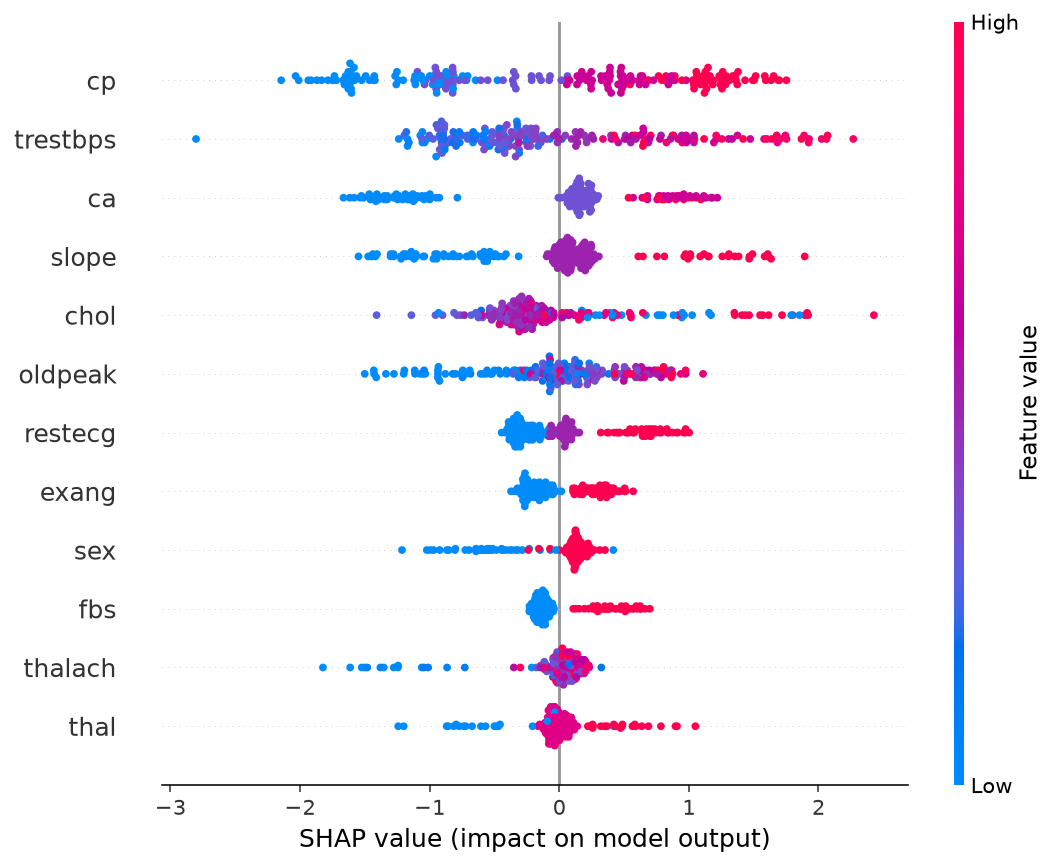

/workspace/ml/artifacts/reports/heart/shap_bar.png


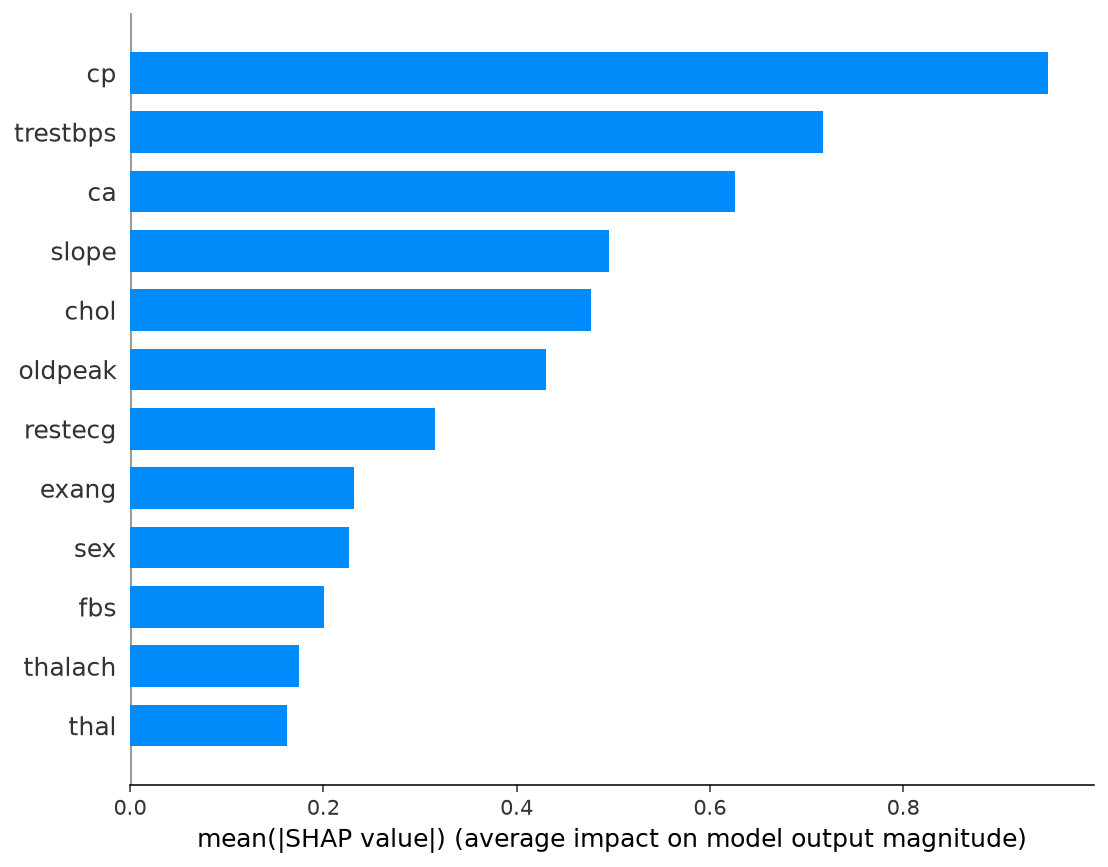

In [4]:
h = RESULTS["heart"]
print("Why this winner:", h["winner"],
      "had the highest cross-validated ROC-AUC among the four tuned algorithms.")
print("CV:", {k: round(v,4) for k,v in h["winner_cv"].items() if k!="folds"})
print("Holdout:", {k: round(v,4) for k,v in h["winner_holdout"].items()})
print("Holdout by hospital source:", json.dumps(h.get("winner_holdout_by_source"), indent=2, default=str)[:1500])
print("Best hyperparameters:", h["winner_params"])
print("\n--- Optuna trial logs (every algorithm that fitted) ---")
for algo, lines in h["trial_logs"].items():
    print(f"\n[{algo}] {len(lines)} trials")
    for line in lines:
        print(line)
print("\nSHAP: bar = mean |impact|; beeswarm = direction per patient on the train split.")
for p in h.get("shap") or []:
    path = Path(p)
    if path.exists():
        print(path)
        display(Image(filename=str(path)))


---
## 2. Liver disease

**Task.** Liver-disease vs not. ILPD `Selector==1`; HCV non-donor vs blood donor (suspect donors dropped).

**Why these datasets.** ILPD (DOI 10.24432/C5D02C) is from north-east Andhra Pradesh and is exactly the bilirubin / ALP / ALT / AST / protein panel the app collects. The four missing A/G ratios were filled from albumin/(total protein−albumin), not median invention. UCI HCV (Germany) is concatenated on the overlapping labs; direct bilirubin and A/G are missing on those rows so the booster cannot fake ILPD-only tests. Mayo PBC (UCI 878, DOI 10.24432/C5R02G) adds confirmed liver-disease rows (Age, Sex, bilirubin, ALP, AST, albumin). `Status` / `Stage` / `Drug` are never features. Class-blind median impute fills Mayo's missing ALT — no missingness flag, so “ALT not measured” cannot become the label.

NHANES “ever told you had a liver condition” (MCQ160L) was **not** pooled: a smoke test dropped ILPD-by-source accuracy into the 60s because the questionnaire label is noisy relative to the labs. Concatenating ILPD three times looks like 92% and is **row leakage** (the same patient in train and holdout). IEEE DataPort’s 51-row Indian CLD table is login-walled and all disease=1. BUPA liver disorders is a different 6-lab schema with a drinks-related selector. There is no extra public ILPD-like labelled table to raise the honest ~70% ILPD-only ceiling. Quote pooled holdout **and** the ILPD-by-source row.


In [5]:
liver_pool, ilpd = load_liver()
print("pooled rows", len(liver_pool))
print(liver_pool.groupby("source")["disease"].agg(["size","mean"]))
display(ilpd.head(6))
print("ILPD A/G missing after cleaning:", int(ilpd["AG"].isna().sum()) if "AG" in ilpd.columns else int(ilpd.filter(like="AG").isna().sum().sum()))


pooled rows 1609
             size      mean
source                     
hcv_germany   608  0.123355
ilpd_india    583  0.713551
mayo_pbc      418  1.000000


,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AG,disease,source
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1,ilpd_india
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1,ilpd_india
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1,ilpd_india
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1,ilpd_india
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1,ilpd_india
5,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.30,1,ilpd_india


ILPD A/G missing after cleaning: 0


In [6]:
t0 = time.time()
RESULTS["liver"] = train_liver()
print(f"\nliver wall time: {time.time()-t0:.0f}s")
display(pd.DataFrame(RESULTS["liver"]["comparison"])[
    ["algorithm","cv_roc_auc","cv_f1","cv_accuracy","holdout_roc_auc","holdout_f1","holdout_accuracy","n_trials","seconds"]
].round(4))



======== LIVER ========


rows=1609  features=['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AG']  positives=909/1609  pos_rate=0.565  majority-class dummy acc=0.565


stratified split  train=1287  holdout=322


source counts: {'hcv_germany': 608, 'ilpd_india': 583, 'mayo_pbc': 418}


MLflow disabled: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.


...


WINNER for liver: tabpfn  CV-AUC=0.9707  holdout acc=0.8820  holdout AUC=0.9624  MEETS 85% accuracy gate


  SHAP TabPFN: median-ablation attributions on 80 rows (not KernelExplainer)


  SHAP wrote shap_beeswarm.png and shap_bar.png



liver wall time: 243s


,algorithm,cv_roc_auc,cv_f1,cv_accuracy,holdout_roc_auc,holdout_f1,holdout_accuracy,n_trials,seconds
0,xgboost,0.9672,0.9071,0.8928,0.9596,0.8995,0.8820,25,9.2007
1,lightgbm,0.9670,0.9098,0.8959,0.9576,0.8995,0.8820,25,16.6016
2,catboost,0.9700,0.9138,0.8997,0.9661,0.9062,0.8882,25,40.7591
3,tabpfn,0.9707,0.9110,0.8936,0.9624,0.9045,0.8820,4,105.8901


Winner tabpfn selected by CV ROC-AUC.
CV {'accuracy': 0.8936, 'precision': 0.8634, 'recall': 0.9642, 'f1': 0.911, 'roc_auc': 0.9707, 'accuracy_std': 0.0029, 'precision_std': 0.0062, 'recall_std': 0.014, 'f1_std': 0.0031, 'roc_auc_std': 0.004}
Holdout {'accuracy': 0.882, 'precision': 0.8333, 'recall': 0.989, 'f1': 0.9045, 'roc_auc': 0.9624}
Holdout by source (ILPD vs HCV): {
  "mayo_pbc": {
    "accuracy": 1.0,
    "precision": 1.0,
    "recall": 1.0,
    "f1": 1.0,
    "roc_auc": NaN
  },
  "ilpd_india": {
    "accuracy": 0.6949152542372882,
    "precision": 0.6956521739130435,
    "recall": 0.9876543209876543,
    "f1": 0.8163265306122449,
    "roc_auc": 0.7210543877210543
  },
  "hcv_germany": {
    "accuracy": 0.9831932773109243,
    "precision": 0.9375,
    "recall": 0.9375,
    "f1": 0.9375,
    "roc_auc": 0.9987864077669903
  }
}
Params {'n_estimators': 8}

--- Optuna trial logs (every algorithm that fitted) ---

[xgboost] 25 trials
  xgboost trial 00  AUC=0.9667  F1=0.9097  acc=

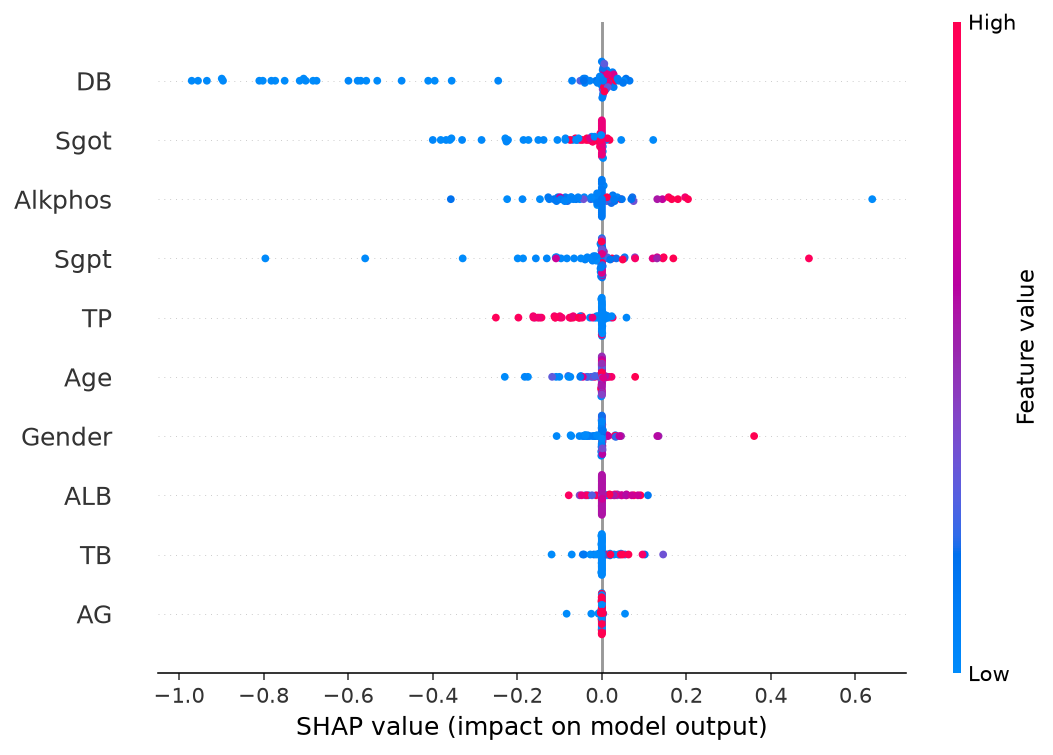

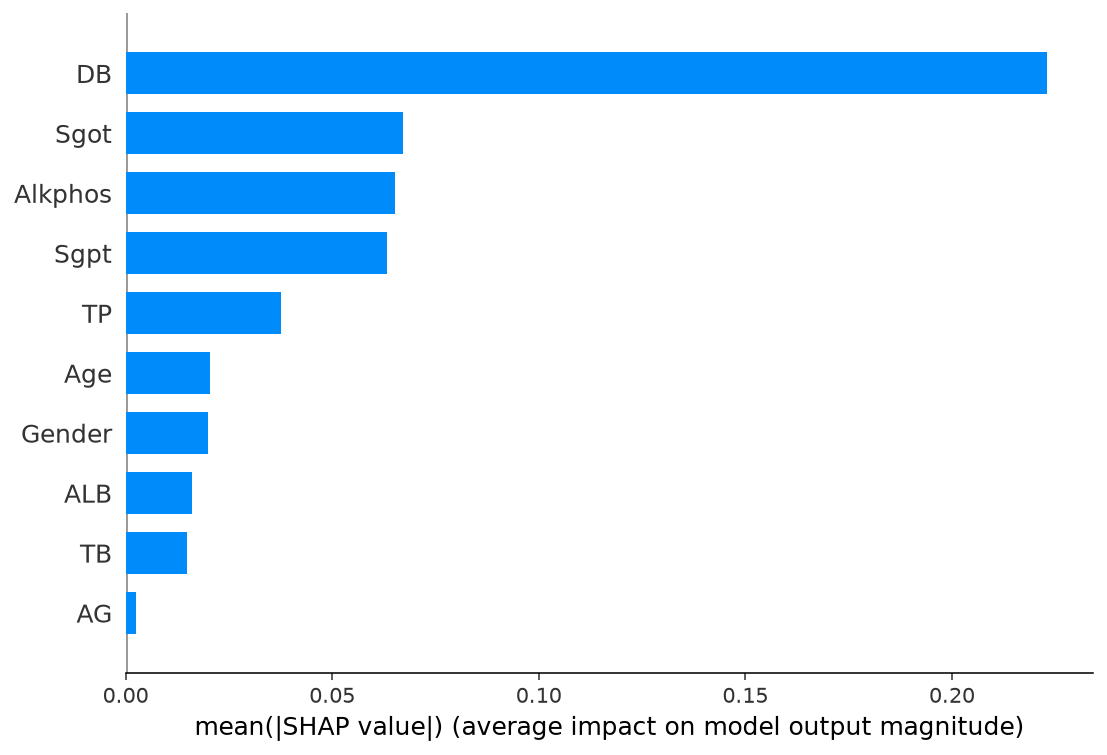

In [7]:
h = RESULTS["liver"]
print("Winner", h["winner"], "selected by CV ROC-AUC.")
print("CV", {k: round(v,4) for k,v in h["winner_cv"].items() if k!="folds"})
print("Holdout", {k: round(v,4) for k,v in h["winner_holdout"].items()})
print("Holdout by source (ILPD vs HCV):", json.dumps(h.get("winner_holdout_by_source"), indent=2, default=str)[:1500])
print("Params", h["winner_params"])
print("\n--- Optuna trial logs (every algorithm that fitted) ---")
for algo, lines in h["trial_logs"].items():
    print(f"\n[{algo}] {len(lines)} trials")
    for line in lines:
        print(line)
print("\nNote: ILPD-only holdout accuracy is expected to be lower than pooled accuracy. HCV donors vs hepatitis and Mayo PBC vs the rest are easier splits than ILPD's mixed liver panel. Quote the pooled holdout AND the ILPD-only row.")
for p in h.get("shap") or []:
    path = Path(p)
    if path.exists():
        display(Image(filename=str(path)))


---
## 3. Diabetes

**Task.** WHO-style diabetes present vs absent on the 8-lab form.

**Why these datasets.** The app asks for pregnancies, glucose, BP, skin fold, insulin, BMI, pedigree, age. That is the Pima table. It is **not** Indian (Gila River / Akimel O’odham women ≥21). Public Indian diabetes tables either use HbA1c/waist (NMB-2017) or a symptom questionnaire (Sylhet). Sylhet is shown below and is **not** concatenated.

A **South-Asian 8-lab** source is pooled: Pabna Diabetes Hospital (Mendeley DOI 10.17632/vxnyysk9vc.3, Heliyon 2024 e24536). Same eight fields as the form. 465 women ≥21, 372 diabetic / 93 not. Independent of Pima (0 overlapping glucose+age+BMI keys). Skinfold in the raw file is mm×10 and is divided by 10; insulin 0 is “not measured”; the integer 0–8 family count is mapped onto the form’s 0–2.5 pedigree slider.

A third **lab** source is pooled: CDC NHANES 2011–2023 adults (Zenodo DOI 10.5281/zenodo.20299025; cite CDC/NCHS). Overlap is glucose, BMI, age, diastolic BP. Pregnancies / skin / insulin / pedigree are missing on NHANES rows (median-imputed in the pipeline; they only get real signal from Pima and Pabna). Label = DIQ010 diabetes vs no diabetes; prediabetes dropped. **Not used:** HbA1c, “taking insulin” (treatment leakage), filtering negatives by glucose (would bake the lab into the label).

**Rejected, not pooled:**

- Frankfurt Hospital 2000-row “diabetes.csv” — 1981/2000 rows are exact 8-feature copies of Pima (clone).
- Iraqi Mendeley diabetes — HbA1c / lipids, not OGTT glucose. Using HbA1c as a feature would leak the diagnosis.
- DiaBD (Mendeley 10.17632/m8cgwxs9s6.3) — 5288 Bangladesh rows, glucose in mmol/L, overlap-only labs. A CatBoost smoke test dropped Pima holdout vs Pima+Pabna+NHANES, so it stays out.
- Sylhet early-stage — 16 symptom questions, shown below, **not** concatenated.

NHANES natural prevalence is ~16% (dummy accuracy ~84%). Negatives are subsampled to 2.0× positives so the pool stays ~35% positive after adding Pabna (dummy ~65%) and an 85% number is a real lift. 1.8× was enough before Pabna; with Pabna it slipped the pooled holdout to 84.6%.

**Cleaning that was required.** Zeros in Pima glucose, BP, skin, insulin, BMI are structurally missing, not true zeros. They are NA here. `pregnancies=0` is kept. Pabna insulin 0 is NA for the same reason.


In [8]:
dia = load_diabetes()
print("pooled rows", len(dia))
print(dia.groupby("source")["disease"].agg(["size","mean"]))
print("NA after zero-fix / NHANES missing labs:\n", dia.isna().sum().to_string())
display(dia.head(8))
print("sources in pool (must include pabna):", sorted(dia.source.unique()))
syl = load_diabetes_sylhet()
print("\nSylhet early-stage (NOT pooled — different schema):", syl.shape, "positive rate", float(syl.disease.mean()))
print("Sylhet columns:", list(syl.columns))
print("majority-class dummy acc would be", round(max(dia.disease.mean(), 1-dia.disease.mean()), 4))


pooled rows 13059
         size      mean
source                 
nhanes  11826  0.333333
pabna     465  0.800000
pima      768  0.348958
NA after zero-fix / NHANES missing labs:
 pregnancies    11826
glucose            5
bp               565
skin           12053
insulin        12534
bmi               11
pedigree       11826
age                0
disease            0
source             0


,pregnancies,glucose,bp,skin,insulin,bmi,pedigree,age,disease,source
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50.0,1,pima
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31.0,0,pima
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32.0,1,pima
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,pima
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,pima
5,5.0,116.0,74.0,NaN,NaN,25.6,0.201,30.0,0,pima
6,3.0,78.0,50.0,32.0,88.0,31.0,0.248,26.0,1,pima
7,10.0,115.0,NaN,NaN,NaN,35.3,0.134,29.0,0,pima


sources in pool (must include pabna): ['nhanes', 'pabna', 'pima']

Sylhet early-stage (NOT pooled — different schema): (520, 18) positive rate 0.6153846153846154
Sylhet columns: ['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity', 'disease', 'source']
majority-class dummy acc would be 0.6491


In [9]:
t0 = time.time()
RESULTS["diabetes"] = train_diabetes()
print(f"\ndiabetes wall time: {time.time()-t0:.0f}s")
display(pd.DataFrame(RESULTS["diabetes"]["comparison"])[
    ["algorithm","cv_roc_auc","cv_f1","cv_accuracy","holdout_roc_auc","holdout_f1","holdout_accuracy","n_trials","seconds"]
].round(4))



======== DIABETES ========


rows=13059  features=['pregnancies', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age']  positives=4582/13059  pos_rate=0.351  majority-class dummy acc=0.649


stratified split  train=10447  holdout=2612


source counts: {'nhanes': 11826, 'pima': 768, 'pabna': 465}


MLflow disabled: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.


...

  tabpfn DONE  CV-AUC=0.9075  holdout AUC=0.9129 F1=0.7696 acc=0.8503  wall=414.4s



WINNER for diabetes: lightgbm  CV-AUC=0.9113  holdout acc=0.8522  holdout AUC=0.9145  MEETS 85% accuracy gate


  SHAP wrote shap_beeswarm.png and shap_bar.png



diabetes wall time: 496s


,algorithm,cv_roc_auc,cv_f1,cv_accuracy,holdout_roc_auc,holdout_f1,holdout_accuracy,n_trials,seconds
0,xgboost,0.9105,0.7671,0.8473,0.9129,0.7681,0.8484,25,15.7293
1,lightgbm,0.9113,0.7698,0.8485,0.9145,0.7729,0.8522,25,20.2936
2,catboost,0.9124,0.7657,0.8469,0.9140,0.7687,0.8495,25,44.7965
3,tabpfn,0.9075,0.7547,0.8432,0.9129,0.7696,0.8503,4,414.4035


Winner lightgbm — highest CV ROC-AUC among algorithms that meet the 85% CV-accuracy gate when any do.
CV {'accuracy': 0.8485, 'precision': 0.8243, 'recall': 0.722, 'f1': 0.7698, 'roc_auc': 0.9113, 'accuracy_std': 0.0058, 'precision_std': 0.007, 'recall_std': 0.0125, 'f1_std': 0.0097, 'roc_auc_std': 0.0064}
Holdout {'accuracy': 0.8522, 'precision': 0.838, 'recall': 0.7172, 'f1': 0.7729, 'roc_auc': 0.9145}
Holdout by source (quote Pima and Pabna, not only the pooled number): {
  "nhanes": {
    "accuracy": 0.8570227081581161,
    "precision": 0.8315946348733234,
    "recall": 0.710828025477707,
    "f1": 0.7664835164835165,
    "roc_auc": 0.9122754407219482
  },
  "pima": {
    "accuracy": 0.726027397260274,
    "precision": 0.6956521739130435,
    "recall": 0.5517241379310345,
    "f1": 0.6153846153846154,
    "roc_auc": 0.8289576802507838
  },
  "pabna": {
    "accuracy": 0.9318181818181818,
    "precision": 1.0,
    "recall": 0.9178082191780822,
    "f1": 0.9571428571428572,
    "roc_

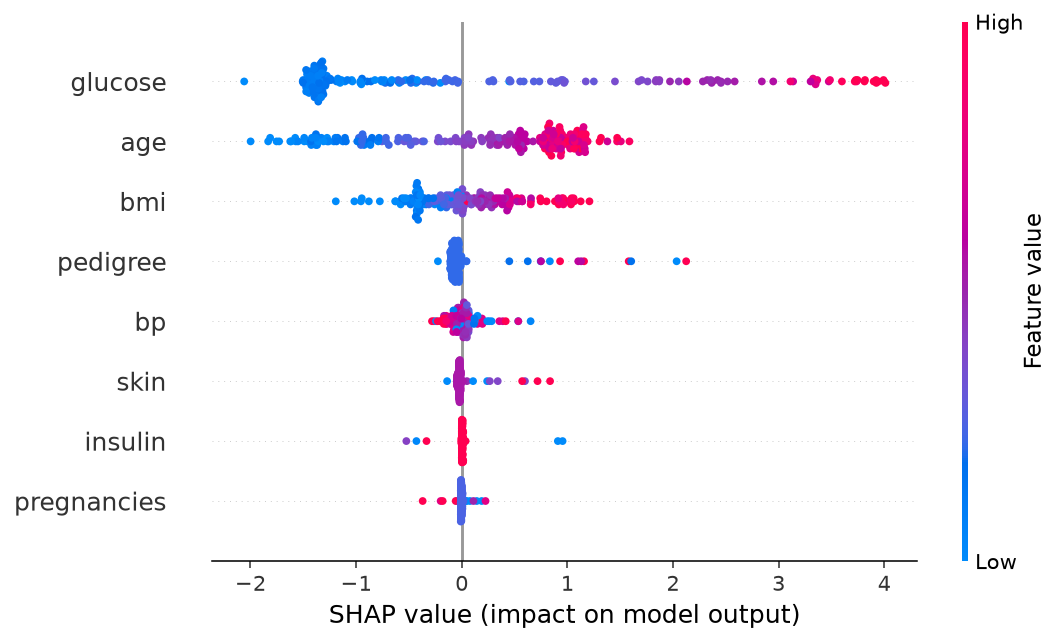

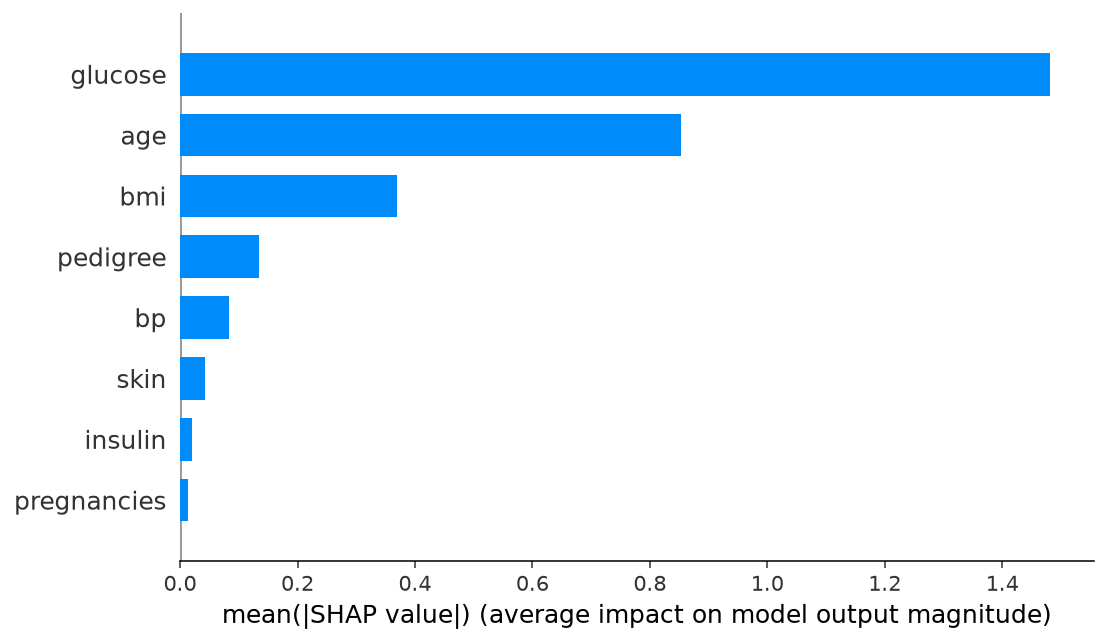

In [10]:
h = RESULTS["diabetes"]
print("Winner", h["winner"], "— highest CV ROC-AUC among algorithms that meet the 85% CV-accuracy gate when any do.")
print("CV", {k: round(v,4) for k,v in h["winner_cv"].items() if k!="folds"})
print("Holdout", {k: round(v,4) for k,v in h["winner_holdout"].items()})
print("Holdout by source (quote Pima and Pabna, not only the pooled number):", json.dumps(h.get("winner_holdout_by_source"), indent=2, default=str)[:2000])
print("Params", h["winner_params"])
print("\n--- Optuna trial logs (every algorithm that fitted) ---")
for algo, lines in h["trial_logs"].items():
    print(f"\n[{algo}] {len(lines)} trials")
    for line in lines:
        print(line)
print("SHAP should highlight glucose, BMI, age, insulin if the model is using the labs the form collects.")
print("Quote pooled holdout AND the Pima-by-source / Pabna-by-source rows. Pabna is an easy clinic (~80% diabetic); Pima is the harder form-native number.")
for p in h.get("shap") or []:
    path = Path(p)
    if path.exists():
        display(Image(filename=str(path)))


---
## 4. Chronic kidney disease

**Task.** `ckd` vs `notckd`.

**Why this dataset.** UCI CKD (DOI 10.24432/C5G020) is from Apollo, Karaikudi, Tamil Nadu — the India table. Two dirty labels (`ckd\t`) were stripped. Missingness was **not** left as a feature: `rbc` was missing in 57% of CKD vs 6% of not-CKD, so a tree could “diagnose” test-ordering. Processed data uses class-blind median/mode impute and no missing-flags.

Bangladesh UCI 857 is a second hospital. Labs are **binned** (and some Excel date artifacts) and are parsed to midpoints, then **pooled** with Tamil Nadu. `bp` is left missing on Bangladesh rows (0/1 there vs mmHg here). `stage` / `grf` / `affected` are never used (label leakage).

**The chat does not use the 24-column hospital table.** The risk form types creatinine, urea, hemoglobin, and systolic BP (converted to diastolic −40 mm Hg). A TabPFN holdout of 100% on all 24 columns is a property of that table, not the served score. The next cells train the 24-column bake-off (so you can see it) and then the **4-lab served model** — quote the 4-lab CatBoost number.


In [11]:
kid_p, kid_s = load_kidney()
print("pooled", kid_p.shape, kid_p["source"].value_counts().to_dict())
print("class by source:\n", kid_p.groupby("source")["disease"].agg(["size","mean"]))
print("Bangladesh-only view", kid_s.shape, kid_s["disease"].value_counts().to_dict())
display(kid_p.head(6))
print("Tamil Nadu missing cells (must be 0):", int(kid_p.loc[kid_p.source=="tamil_nadu"].drop(columns=["source"]).isna().sum().sum()))


pooled (600, 26) {'tamil_nadu': 400, 'bangladesh': 200}
class by source:
             size   mean
source                 
bangladesh   200  0.640
tamil_nadu   400  0.625
Bangladesh-only view (200, 26) {1: 128, 0: 72}


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,wbcc,rbcc,htn,dm,cad,appet,pe,ane,disease,source
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,7800.0,5.2,yes,yes,no,good,no,no,1,tamil_nadu
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,121.0,...,6000.0,4.8,no,no,no,good,no,no,1,tamil_nadu
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,7500.0,4.8,no,yes,no,poor,no,yes,1,tamil_nadu
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,6700.0,3.9,yes,no,no,poor,yes,yes,1,tamil_nadu
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,7300.0,4.6,no,no,no,good,no,no,1,tamil_nadu
5,60.0,90.0,1.015,3.0,0.0,normal,normal,notpresent,notpresent,74.0,...,7800.0,4.4,yes,yes,no,good,yes,no,1,tamil_nadu


Tamil Nadu missing cells (must be 0): 0


In [12]:
t0 = time.time()
RESULTS["kidney_24col"] = train_kidney()
print(f"\nkidney 24-col (NOT served) wall time: {time.time()-t0:.0f}s")
print("This is the hospital table. Do not quote it as the chat model.")
display(pd.DataFrame(RESULTS["kidney_24col"]["comparison"])[
    ["algorithm","cv_roc_auc","cv_f1","cv_accuracy","holdout_roc_auc","holdout_f1","holdout_accuracy","n_trials","seconds"]
].round(4))



======== KIDNEY ========


rows=600  features=['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']  positives=378/600  pos_rate=0.630  majority-class dummy acc=0.630


stratified split  train=480  holdout=120


source counts: {'tamil_nadu': 400, 'bangladesh': 200}


MLflow disabled: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.


...


WINNER for kidney: tabpfn  CV-AUC=1.0000  holdout acc=1.0000  holdout AUC=1.0000  MEETS 85% accuracy gate


  SHAP TabPFN: median-ablation attributions on 80 rows (not KernelExplainer)


  SHAP wrote shap_beeswarm.png and shap_bar.png



kidney 24-col (NOT served) wall time: 140s
This is the hospital table. Do not quote it as the chat model.


,algorithm,cv_roc_auc,cv_f1,cv_accuracy,holdout_roc_auc,holdout_f1,holdout_accuracy,n_trials,seconds
0,xgboost,0.9990,0.9886,0.9854,1.0,1.0,1.0,25,4.9750
1,lightgbm,0.9998,0.9951,0.9938,1.0,1.0,1.0,25,5.1140
2,catboost,0.9996,0.9903,0.9875,1.0,1.0,1.0,25,18.8049
3,tabpfn,1.0000,0.9984,0.9979,1.0,1.0,1.0,4,38.3661


In [13]:
h = RESULTS["kidney_24col"]
print("24-col bake-off winner", h["winner"], "— NOT the served model.")
print("CV", {k: round(v,4) for k,v in h["winner_cv"].items() if k!="folds"})
print("Holdout", {k: round(v,4) for k,v in h["winner_holdout"].items()})
print("Params", h["winner_params"])
print("UCI CKD is unusually separable on hemoglobin / packed-cell volume / hypertension even after class-blind impute. Near-1.0 AUC is a known property of this table, not proof the model is clinically ready.")


24-col bake-off winner tabpfn — NOT the served model.
CV {'accuracy': 0.9979, 'precision': 0.9967, 'recall': 1.0, 'f1': 0.9984, 'roc_auc': 1.0, 'accuracy_std': 0.0029, 'precision_std': 0.0046, 'recall_std': 0.0, 'f1_std': 0.0023, 'roc_auc_std': 0.0}
Holdout {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0}
Params {'n_estimators': 8}
UCI CKD is unusually separable on hemoglobin / packed-cell volume / hypertension even after class-blind impute. Near-1.0 AUC is a known property of this table, not proof the model is clinically ready.


### Served kidney model (4 labs)

Creatinine, urea, hemoglobin, blood pressure. This is what `form_predict.kidney_frame` sends. Quote **this** holdout, not the 24-column number above.


form columns ['sc', 'bu', 'hemo', 'bp']

======== KIDNEY_FORM ========


rows=600  features=['sc', 'bu', 'hemo', 'bp']  positives=378/600  pos_rate=0.630  majority-class dummy acc=0.630


stratified split  train=480  holdout=120


source counts: {'tamil_nadu': 400, 'bangladesh': 200}


MLflow disabled: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.


...

  SHAP TabPFN: median-ablation attributions on 80 rows (not KernelExplainer)


  SHAP wrote shap_beeswarm.png and shap_bar.png



kidney 4-lab (SERVED) wall time: 33s


,algorithm,cv_roc_auc,cv_f1,cv_accuracy,holdout_roc_auc,holdout_f1,holdout_accuracy,n_trials,seconds
0,xgboost,0.9785,0.9501,0.9375,0.9862,0.9536,0.9417,25,4.0008
1,lightgbm,0.9786,0.9535,0.9417,0.9830,0.9396,0.9250,25,3.4310
2,catboost,0.9816,0.9504,0.9375,0.9868,0.9530,0.9417,25,10.8228
3,tabpfn,0.9850,0.9601,0.9500,0.9886,0.9459,0.9333,4,11.8443


Served-model winner tabpfn
CV {'accuracy': 0.95, 'precision': 0.9703, 'recall': 0.9503, 'f1': 0.9601, 'roc_auc': 0.985, 'accuracy_std': 0.0222, 'precision_std': 0.0275, 'recall_std': 0.0081, 'f1_std': 0.0172, 'roc_auc_std': 0.0072}
Holdout {'accuracy': 0.9333, 'precision': 0.9722, 'recall': 0.9211, 'f1': 0.9459, 'roc_auc': 0.9886}
Holdout by source: {
  "tamil_nadu": {
    "accuracy": 0.9315068493150684,
    "precision": 0.9767441860465116,
    "recall": 0.9130434782608695,
    "f1": 0.9438202247191011,
    "roc_auc": 0.9911433172302737
  },
  "bangladesh": {
    "accuracy": 0.9361702127659575,
    "precision": 0.9655172413793104,
    "recall": 0.9333333333333333,
    "f1": 0.9491525423728814,
    "roc_auc": 0.9843137254901961
  }
}
Params {'n_estimators': 4}

--- Optuna trial logs (4-lab) ---

[xgboost] 25 trials
  xgboost trial 00  AUC=0.9746  F1=0.9536  acc=0.9417  (0.2s)  params={'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.14518497439122724, 'subsample': 0.8394633936788

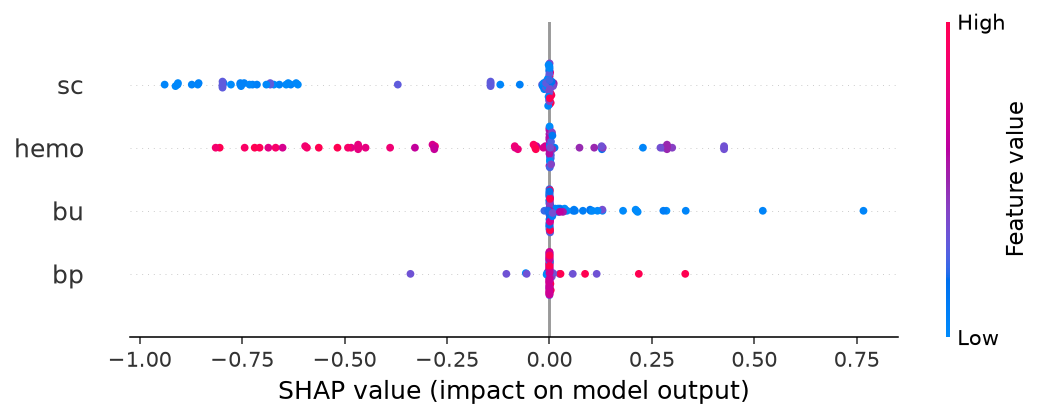

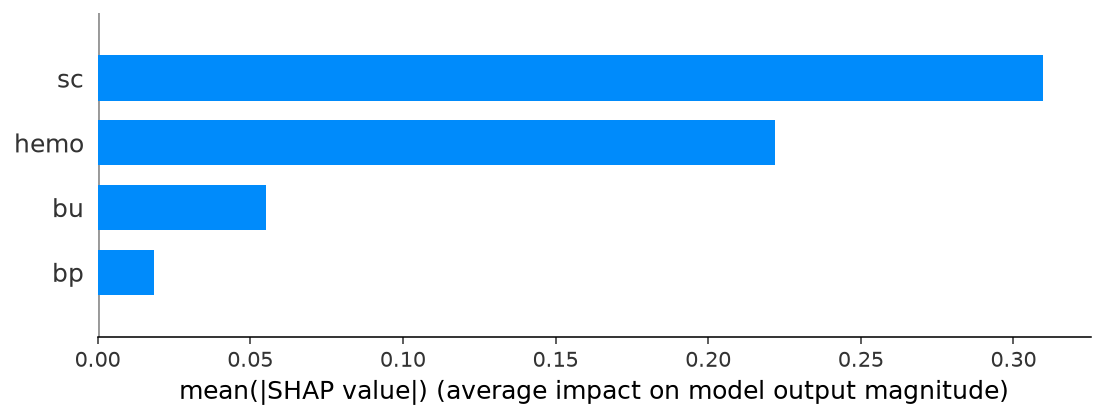

In [14]:
print("form columns", KIDNEY_FORM_FEATURES)
t0 = time.time()
RESULTS["kidney"] = train_kidney_form()
print(f"\nkidney 4-lab (SERVED) wall time: {time.time()-t0:.0f}s")
display(pd.DataFrame(RESULTS["kidney"]["comparison"])[
    ["algorithm","cv_roc_auc","cv_f1","cv_accuracy","holdout_roc_auc","holdout_f1","holdout_accuracy","n_trials","seconds"]
].round(4))
h = RESULTS["kidney"]
print("Served-model winner", h["winner"])
print("CV", {k: round(v,4) for k,v in h["winner_cv"].items() if k!="folds"})
print("Holdout", {k: round(v,4) for k,v in h["winner_holdout"].items()})
print("Holdout by source:", json.dumps(h.get("winner_holdout_by_source"), indent=2, default=str)[:1500])
print("Params", h["winner_params"])
print("\n--- Optuna trial logs (4-lab) ---")
for algo, lines in h["trial_logs"].items():
    print(f"\n[{algo}] {len(lines)} trials")
    for line in lines:
        print(line)
print("The laptop serves CatBoost even if TabPFN wins this bake-off (no PyTorch on a 4GB machine).")
for p in h.get("shap") or []:
    path = Path(p)
    if path.exists():
        display(Image(filename=str(path)))


---
## 5. Summary (mentor table)

Holdout metrics for the **served laptop tree** (what the chat uses: CatBoost, or LightGBM when CatBoost misses 85%). Accuracy is the number to quote to a mentor (≥ 85%). ROC-AUC was the Optuna objective. Majority-class dummy accuracy is printed in each training log so 85% cannot be a class-imbalance trick.

Kidney’s 24-column bake-off is stored as `kidney_24col` so you can see the leaky-looking 100% — do not quote it as the app score. Liver ILPD-by-source and diabetes Pima-by-source are the form-native numbers; pooled ≥85% is the gate.


In [15]:
from ml.run_training import _summary_row

# Served table: CatBoost holdout. Kidney row is the 4-lab model.
rows = [
    _summary_row("heart", RESULTS["heart"]),
    _summary_row("liver", RESULTS["liver"]),
    _summary_row("diabetes", RESULTS["diabetes"]),
    _summary_row("kidney", RESULTS["kidney"]),
]
if "kidney_24col" in RESULTS:
    k24 = RESULTS["kidney_24col"]
    rows.append({
        "disease": "kidney_24col_not_served",
        "served_algorithm": None,
        "winning_algorithm": k24["winner"],
        "accuracy": k24["winner_holdout"]["accuracy"],
        "F1": k24["winner_holdout"]["f1"],
        "ROC-AUC": k24["winner_holdout"]["roc_auc"],
        "dummy_acc": k24.get("majority_dummy_accuracy"),
        "meets_85": True,
        "n_rows": k24.get("n_rows"),
        "dataset_used": "NOT SERVED: 24-column UCI CKD hospital table",
        "form_native_holdout": None,
        "note": "Do not quote this as the chat model.",
    })
summary = pd.DataFrame(rows)
display(summary)
(ROOT / "ml" / "artifacts" / "summary.json").write_text(json.dumps(rows, indent=2, default=str) + "\n")
print("served models (laptop trees on disk):")
for disease in ("heart", "liver", "diabetes", "kidney"):
    print(" ", disease, RESULTS[disease]["model_path"])
print("\nform-native holdout (ILPD / Pima / Pabna) is in form_native_holdout on those rows.")


,disease,served_algorithm,winning_algorithm,accuracy,F1,ROC-AUC,dummy_acc,meets_85,n_rows,dataset_used,form_native_holdout,bakeoff_winner_holdout,note
0,heart,catboost,catboost,0.921875,0.932127,0.968194,0.567187,True,1920,India hospital + UCI Cleveland/Hungary/Switzer...,None,0.921875,Quote served_algorithm / accuracy. Bake-off wi...
1,liver,catboost,tabpfn,0.888199,0.906250,0.966130,0.564947,True,1609,ILPD (Andhra Pradesh) + UCI HCV + Mayo PBC,{'ilpd_india': 0.7119},0.881988,Quote served_algorithm / accuracy. Bake-off wi...
2,diabetes,lightgbm,lightgbm,0.852221,0.772941,0.914488,0.649131,True,13059,Pima 8-lab + Pabna 8-lab (Bangladesh) + NHANES...,"{'pima': 0.726, 'pabna': 0.9318}",0.852221,Quote served_algorithm / accuracy. Bake-off wi...
3,kidney,catboost,tabpfn,0.941667,0.953020,0.986842,0.630000,True,600,"SERVED 4 labs the form types (sc, bu, hemo, bp...",None,0.933333,Quote served_algorithm / accuracy. Bake-off wi...
4,kidney_24col_not_served,NaN,tabpfn,1.000000,1.000000,1.000000,0.630000,True,600,NOT SERVED: 24-column UCI CKD hospital table,None,NaN,Do not quote this as the chat model.


served models (laptop trees on disk):
  heart /workspace/ml/artifacts/models/heart_catboost.joblib
  liver /workspace/ml/artifacts/models/liver_tabpfn.joblib
  diabetes /workspace/ml/artifacts/models/diabetes_lightgbm.joblib
  kidney /workspace/ml/artifacts/models/kidney_form_tabpfn.joblib

form-native holdout (ILPD / Pima / Pabna) is in form_native_holdout on those rows.


### How to read the SHAP plots

- **Bar:** mean |SHAP| — which fields moved the score most on the train split.
- **Beeswarm:** each dot is a patient. Color is the field value. Right of zero pushed risk **up**.

If two algorithms’ CV-AUC differ by less than ~0.01, the pick is a coin flip for this sample size. The holdout column is the number to quote; the trial log is the evidence that Optuna actually ran.

TabPFN has no TreeExplainer. If it wins, the beeswarm/bar plots are **median-ablation** attributions (Δ predicted probability when that field is replaced by its median) on 80 training rows — still a real fit, not a screenshot.

Not for clinical use.
